In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_wrangling import *
from bayes_opt import BayesianOptimization

In [49]:
def myround(x, base=5):
    return base * round(x/base)

def calculate_sharpe_ratio(pnl_series):
    returns = pnl_series.pct_change().dropna()
    sharpe_ratio = np.mean(returns) / np.std(returns)
    return sharpe_ratio * np.sqrt(252)

def calculate_sortino_ratio(pnl_series):
    returns = pnl_series.pct_change().dropna()
    sortino_ratio = np.mean(returns) / np.std(returns[returns < 0])
    return sortino_ratio * np.sqrt(252)

def ensure_weekly_action(df):
    last_action = 0
    last_week = -1

    for i in range(len(df)):
        current_week = df.index[i].isocalendar()[1]  # Get the week number
        current_day = df["day"].iloc[i]

        if current_week != last_week:  # Reset at the start of a new week
            last_action = 0
            last_week = current_week

        if last_action != 0 and df["action"].iloc[i] != 0:
            # If an action has already occurred this week, set to 0
            df.at[df.index[i], "action"] = 0
        elif df["action"].iloc[i] != 0:
            # If this is the first action of the week, update last_action
            last_action = df["action"].iloc[i]

    return df

def find_nearest_strike_delta(atm_spot, date_index, delta_target, option_df, cp_flag):
    """
    Helper function to find the strike with delta closest to delta_target
    """

    options = option_df.loc[date_index].query(f"cp_flag == '{cp_flag}'")
    atm_delta = options.query("strike_price == @atm_spot")["delta"]
    try:
        if isinstance(atm_delta, pd.Series):
            atm_delta = atm_delta.values[0]
    except IndexError:
        print(f"Error: {date_index}, {cp_flag}")
        return None
    new_delta = atm_delta + delta_target
    return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]

class Option:
    def __init__(self, strike: float, premium: float, expiry: str):
        self.strike = strike
        self.premium = premium
        self.expiry = expiry
        self.spot_price = None

    def insert_spot(self, spot_price: float):
        self.spot_price = spot_price
    
    def short_call(self):
        # Payoff for short call: premium received - intrinsic value of the option
        intrinsic_value = np.maximum(0, self.spot_price - self.strike)
        return self.premium - intrinsic_value
    
    def long_call(self):
        # Payoff for long call: intrinsic value - premium paid
        intrinsic_value = np.maximum(0, self.spot_price - self.strike)
        return intrinsic_value - self.premium
    
    def short_put(self):
        # Payoff for short put: premium received - intrinsic value of the option
        intrinsic_value = np.maximum(0, self.strike - self.spot_price)
        return self.premium - intrinsic_value
    
    def long_put(self):
        # Payoff for long put: intrinsic value - premium paid
        intrinsic_value = np.maximum(0, self.strike - self.spot_price)
        return intrinsic_value - self.premium


class IronCondor:
    def __init__(self, direction: str, strikes: dict, premiums: dict, expiry: str):
        """
        Initialize the Iron Condor strategy with strikes and premiums for the options.
        
        direction: long, (short) Iron Condor
        1. Short (Long) 1 OTM Put (strike 1)
        2. Long (Short) 1 close to ATM Put (strike 2)
        3. Long (Short) 1 close to ATM Call (strike 3)
        4. Short (Long) 1 OTM Call (strike 4)        

        strikes: a dictionary of strikes for the 4 options (strike1 to strike4)
        premiums: a dictionary of premiums for the 4 options (premium1 to premium4)
        expiry: expiration date of the options
        """
        self.strikes = strikes
        self.premiums = premiums
        self.direction = direction
        self.expiry = expiry
        self.short_put_option = Option(strikes['strike1'], premiums['premium1'], expiry)
        self.long_put_option = Option(strikes['strike2'], premiums['premium2'], expiry)
        self.long_call_option = Option(strikes['strike3'], premiums['premium3'], expiry)
        self.short_call_option = Option(strikes['strike4'], premiums['premium4'], expiry)

    def initial_cashflow(self):
        """
        Calculate the initial cashflow of the Iron Condor strategy.
        """
        if self.direction == "long":
            initial_cashflow = self.premiums['premium1'] - self.premiums['premium2'] - self.premiums['premium3'] + self.premiums['premium4']
        elif self.direction == "short":
            initial_cashflow = -self.premiums['premium1'] + self.premiums['premium2'] + self.premiums['premium3'] - self.premiums['premium4']
        
        return initial_cashflow

    def insert_spot(self, spot_price: float):
        """
        Insert the current spot price for all the options in the Iron Condor strategy.
        """
        self.short_put_option.insert_spot(spot_price)
        self.long_put_option.insert_spot(spot_price)
        self.long_call_option.insert_spot(spot_price)
        self.short_call_option.insert_spot(spot_price)
    
    def payoff(self):
        """
        Calculate the total payoff (profit or loss) of the Iron Condor strategy.
        
        direction: 'long' for long Iron Condor, 'short' for short Iron Condor
        """
        if self.direction == "long":
            short_put = self.short_put_option.short_put()
            long_put = self.long_put_option.long_put()
            long_call = self.long_call_option.long_call()
            short_call = self.short_call_option.short_call()
            total_payoff = short_put + long_put + long_call + short_call
        elif self.direction == "short":
            long_put = -self.long_put_option.long_put()
            short_put = -self.short_put_option.short_put()
            short_call = -self.short_call_option.short_call()
            long_call = -self.long_call_option.long_call()
            total_payoff = long_put + short_put + short_call + long_call
        
        return total_payoff.iloc[0] if isinstance(total_payoff, pd.Series) else total_payoff
    
    def target_profit(self):
        """
        Calculate the target profit for the Iron Condor strategy.
        """
        if self.direction == "long":
            self.long_call_option = Option(self.strikes['strike3'], self.premiums['premium3'], self.expiry)
            self.short_call_option = Option(self.strikes['strike4'], self.premiums['premium4'], self.expiry)
            self.long_call_option.insert_spot(self.strikes["strike4"] + 5)
            self.short_call_option.insert_spot(self.strikes["strike4"] + 5)
            target_profit = self.premiums["premium1"] - self.premiums["premium2"] + self.long_call_option.long_call() + self.short_call_option.short_call()
        elif self.direction == "short":
            target_profit = self.initial_cashflow()
        
        return target_profit

class OptionsBacktester:
    def __init__(self,
                 signal_df: pd.DataFrame,
                 spot_price_df: pd.DataFrame,
                 options_df: pd.DataFrame,
                 upper_threshold: float,
                 lower_threshold: float,
                 option_type: str,
                 dynamic_option_strategy: bool = False,
                 dynamic_strike: bool = False,):
        self.signal_df = signal_df
        self.signal_df.columns = ["signal"]
        self.spot_price_df = spot_price_df
        self.options_df = options_df
        self.upper_threshold = upper_threshold
        self.lower_threshold = lower_threshold
        self.option_type = option_type
        self.dynamic_option_strategy = dynamic_option_strategy
        self.dynamic_strike = dynamic_strike

        self.comb_df = pd.concat([self.signal_df, self.spot_price_df.shift(), self.options_df.shift()], axis=1)
        self.comb_df["action"] = np.where(self.comb_df["signal"] > self.upper_threshold, 1, np.where(self.comb_df["signal"] < self.lower_threshold, -1, 0))

    def long_short_vol_df(self):
        self.trading_df = {}
        for index, row in self.comb_df.iterrows():
            if row["action"] != 0:
                self.trading_df[index] = self.comb_df.loc[index]

## Filtering of options data

In [16]:
day_map = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

xlu_options = pd.read_hdf("data/etf_options_data.hf5", key="XLU")
xlu_options = xlu_options.set_index("date")
xlu_options["strike_price"] = xlu_options["strike_price"] / 1000
xlu_filtered_options = xlu_options.groupby("date").apply(lambda x: x.query("exdate == exdate.max()")).reset_index(level=0, drop=True)
xlu_filtered_options["day"] = xlu_filtered_options.index.weekday.map(day_map)
xlu_filtered_options["ex_day"] = xlu_filtered_options["exdate"].dt.weekday.map(day_map)
xlu_filtered_options

,ticker,exdate,cp_flag,strike_price,best_bid,best_offer,open_interest,impl_volatility,delta,gamma,theta,vega,volume,day,ex_day
date,,,,,,,,,,,,,,,
2000-01-10,XLU,2000-01-22,C,31.0,0.0000,0.1250,0.0,0.423886,0.068868,0.062562,-4.271427,0.662345,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,P,29.0,1.4375,1.6250,0.0,0.271660,-0.839551,0.179317,-4.941929,1.211415,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,P,30.0,2.3750,2.6250,0.0,0.353248,-0.899561,0.099878,-4.593377,0.872273,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,C,28.0,0.0625,0.1875,0.0,0.143454,0.283783,0.471890,-3.686701,1.692336,0.0,Monday,Saturday
2000-01-10,XLU,2000-01-22,C,27.0,0.5625,0.7500,0.0,0.140491,0.799844,0.397932,-2.952004,1.393989,0.0,Monday,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31,XLU,2023-09-08,P,73.5,10.2000,10.5500,0.0,NaN,NaN,NaN,NaN,NaN,0.0,Thursday,Friday
2023-08-31,XLU,2023-09-08,P,90.0,26.7000,27.2000,0.0,NaN,NaN,NaN,NaN,NaN,0.0,Thursday,Friday
2023-08-31,XLU,2023-09-08,P,72.5,9.3000,9.5500,0.0,NaN,NaN,NaN,NaN,NaN,0.0,Thursday,Friday


In [30]:
def objective_function(window, upper_threshold, lower_threshold):
    try:
        # Options data
        day_map = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

        xlu_options = pd.read_hdf("data/etf_options_data.hf5", key="XLU")
        xlu_options = xlu_options.set_index("date")
        xlu_options["strike_price"] = xlu_options["strike_price"] / 1000
        xlu_filtered_options = xlu_options.groupby("date").apply(lambda x: x.query("exdate == exdate.max()")).reset_index(level=0, drop=True)
        xlu_filtered_options["day"] = xlu_filtered_options.index.weekday.map(day_map)
        xlu_filtered_options["ex_day"] = xlu_filtered_options["exdate"].dt.weekday.map(day_map)

        # Setting time series data
        xlu_pred = pd.read_csv("data/xlu_pred.csv", parse_dates=True, index_col=0).rename(columns={"0": "Rolling Pred"})
        xlu_iv = pd.read_csv("data/XLU_IV.csv", parse_dates=True, index_col=0)
        xlu_vrp = (xlu_iv["Average IV"] - xlu_pred["Rolling Pred"]).dropna()

        xlu_vrp_standardised = rolling_z_score(xlu_vrp, window=int(window))

        xlu_filtered_options["vrp"] = xlu_vrp_standardised
        xlu_time_series = pd.read_hdf("data/etf_series.hf5", key="XLU")
        xlu_time_series["day"] = xlu_time_series.index.weekday
        xlu_time_series["vrp"] = xlu_vrp_standardised
        xlu_time_series["signal"] = np.where(xlu_time_series["vrp"] > upper_threshold, 1, np.where(xlu_time_series["vrp"] < lower_threshold, -1, 0))
        xlu_time_series["action"] = np.where((xlu_time_series["signal"] == 1)  & (xlu_time_series.index.weekday != 4), 1, 
                                            np.where((xlu_time_series["signal"] == -1) & (xlu_time_series.index.weekday != 4), -1, 
                                                    0))
        xlu_time_series.dropna(inplace=True)
        xlu_time_series

        xlu_time_series = ensure_weekly_action(xlu_time_series)
        xlu_time_series["action"] = xlu_time_series["action"].shift(-1)

        # Strategy backtesting
        ironcondor_tracker = {}

        for index, row in xlu_time_series.iterrows():
            if row["action"] == 1:
                print(f"date: {index}")
                direction = "short"

                index_loc = xlu_time_series.index.get_loc(index)

                current_spot_open = myround(xlu_time_series.iloc[index_loc]["Open"], 0.5)

                daily_options = xlu_filtered_options.loc[index]

                atm_put_strike = atm_call_strike = current_spot_open

                otm_put_strike = find_nearest_strike_delta(current_spot_open, index, 0.4, xlu_filtered_options, "P")
                otm_call_strike = find_nearest_strike_delta(current_spot_open, index, -0.3, xlu_filtered_options, "C")

                if otm_put_strike is None or otm_call_strike is None:
                    continue
                    
                else:
                    print(f"date: {index}, current_spot_open: {current_spot_open}, OTM Put: {otm_put_strike}, ATM Put: {atm_put_strike}, ATM Call: {atm_call_strike}, OTM Call: {otm_call_strike}, \
                        left wing: {abs(otm_put_strike - atm_put_strike)}, right wing: {abs(atm_call_strike - otm_call_strike)}")
                    strikes = {
                        "strike1": otm_put_strike,
                        "strike2": atm_put_strike,
                        "strike3": atm_call_strike,
                        "strike4": otm_call_strike
                    }

                    premiums = {
                        "premium1": xlu_filtered_options.loc[
                            (xlu_filtered_options.index == index) & 
                            (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                            (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                        ],
                        "premium2": xlu_filtered_options.loc[
                            (xlu_filtered_options.index == index) & 
                            (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                            (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                        ],
                        "premium3": xlu_filtered_options.loc[
                            (xlu_filtered_options.index == index) & 
                            (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                            (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                        ],
                        "premium4": xlu_filtered_options.loc[
                            (xlu_filtered_options.index == index) & 
                            (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                            (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                        ]
                    }        

                    # print(f"date: {index}, Premiums: {premiums}")

                    expiry = xlu_filtered_options.loc[index]["exdate"].max()

                    ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
                    ironcondor_tracker[index] = (ironcondor, ironcondor.target_profit().iloc[0], expiry)

        # Calculate the payoff of the Iron Condor strategy
        pnl_dict = {}

        for index, (ironcondor, target_profit, expiry) in ironcondor_tracker.items():
            print(f"Processing date: {index}, expiry: {expiry}")
            if ironcondor is not None:

                test_time_series = xlu_time_series.loc[index:expiry + pd.Timedelta(days=1)]
                options_test_df = xlu_filtered_options.loc[index:expiry + pd.Timedelta(days=1)]
                early_close = False

                for date, row in test_time_series.iterrows():
                    if row["signal"] == -1:
                        
                        print(f"Closing on date: {date}")
                        ic_strikes = ironcondor.strikes
                        print(f"strike1: {ic_strikes['strike1']}, strike2: {ic_strikes['strike2']}, strike3: {ic_strikes['strike3']}, strike4: {ic_strikes['strike4']}")

                        try:
                            long_put_buyback = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'P') & 
                                (options_test_df.loc[date]["strike_price"] == ic_strikes["strike1"])
                            ]["best_offer"].values[0]
                        except IndexError:
                            closest_strike = options_test_df.loc[date][options_test_df.loc[date]["cp_flag"] == 'P'] \
                            .assign(distance=lambda x: (x["strike_price"] - ic_strikes["strike1"]).abs()) \
                            .sort_values("distance").iloc[0]["strike_price"]
                            
                            # Select the best offer at the closest strike price
                            long_put_buyback = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'P') &
                                (options_test_df.loc[date]["strike_price"] == closest_strike)
                            ]["best_offer"].values[0]
                        # print(f"Long put buyback: {long_put_buyback}")

                        try:
                            short_put_sellback = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'P') & 
                                (options_test_df.loc[date]["strike_price"] == ic_strikes["strike2"])
                            ]["best_bid"].values[0]
                        except IndexError:
                            closest_strike = options_test_df.loc[date][options_test_df.loc[date]["cp_flag"] == 'P'] \
                            .assign(distance=lambda x: (x["strike_price"] - ic_strikes["strike2"]).abs()) \
                            .sort_values("distance").iloc[0]["strike_price"]
                            
                            # Select the best bid at the closest strike price
                            short_put_sellback = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'P') &
                                (options_test_df.loc[date]["strike_price"] == closest_strike)
                            ]["best_bid"].values[0]
                        # print(f"Short put sellback: {short_put_sellback}")


                        try:
                            short_call_sellback = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'C') & 
                                (options_test_df.loc[date]["strike_price"] == ic_strikes["strike3"])
                            ]["best_bid"].values[0]
                        except IndexError:
                            closest_strike = options_test_df.loc[date][options_test_df.loc[date]["cp_flag"] == 'C'] \
                            .assign(distance=lambda x: (x["strike_price"] - ic_strikes["strike3"]).abs()) \
                            .sort_values("distance").iloc[0]["strike_price"]
                            
                            # Select the best bid at the closest strike price
                            short_call_sellback = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'C') &
                                (options_test_df.loc[date]["strike_price"] == closest_strike)
                            ]["best_bid"].values[0]
                        # print(f"Short call sellback: {short_call_sellback}")

                        try:
                            long_call_buyback = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'C') & 
                                (options_test_df.loc[date]["strike_price"] == ic_strikes["strike4"])
                            ]["best_offer"].values[0]
                        except IndexError:
                            closest_strike = options_test_df.loc[date][options_test_df.loc[date]["cp_flag"] == 'C'] \
                            .assign(distance=lambda x: (x["strike_price"] - ic_strikes["strike4"]).abs()) \
                            .sort_values("distance").iloc[0]["strike_price"]
                            
                            # Select the best offer at the closest strike price
                            long_call_buyback = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'C') &
                                (options_test_df.loc[date]["strike_price"] == closest_strike)
                            ]["best_offer"].values[0]
                        # print(f"Long call buyback: {long_call_buyback}")

                        closing_value = -long_put_buyback + short_put_sellback + short_call_sellback - long_call_buyback
                        print(f"Closing value: {closing_value}")

                        ironcondor.insert_spot(xlu_time_series.loc[date]["Close"])
                        pnl_dict[index] = ironcondor.payoff() + closing_value
                        print(f"Close iron condor early on date: {date} when signal is -1, pnl: {pnl_dict[index]}")
                        early_close = True
                        break
                if not early_close:
                    try:
                        ironcondor.insert_spot(xlu_time_series.loc[expiry]["Close"])
                        print(f"Let iron condor expire: {expiry}, pnl: {ironcondor.payoff()}")
                        pnl_dict[index] = ironcondor.payoff()    
                    except KeyError:
                        try:
                            ironcondor.insert_spot(xlu_time_series.loc[expiry + pd.Timedelta(days=1)]["Close"])
                            print(f"Let iron condor expire: {expiry}, pnl: {ironcondor.payoff()}")
                            pnl_dict[index] = ironcondor.payoff()           
                        except KeyError:
                            try:
                                ironcondor.insert_spot(xlu_time_series.loc[expiry - pd.Timedelta(days=1)]["Close"])
                                print(f"Let iron condor expire: {expiry}, pnl: {ironcondor.payoff()}")
                                pnl_dict[index] = ironcondor.payoff()    
                            except KeyError:
                                print(f"Warning: Unable to insert spot for index {index} with expiry {expiry}, PnL set to 0")
                                pnl_dict[index] = 0
                                continue
                                    
                    
                    # print(f"Let iron condor expire: {expiry}, pnl: {ironcondor.payoff()}")
                    # pnl_dict[index] = ironcondor.payoff()         

        pnl_series = pd.DataFrame(pnl_dict.items(), columns=["Date", "PnL"]).set_index("Date").PnL
        if pnl_series.empty:
            print("Warning: pnl_series is empty. Returning a large negative value to indicate failure.")
            return -10  # Large negative finite value to discourage this parameter set

        # Calculate returns and check standard deviation
        returns = pnl_series.pct_change().dropna()
        if returns.std() == 0:
            print("Warning: Standard deviation of returns is zero. Returning a large negative value.")
            return -10  # Avoid infinite Sharpe by returning -10

        # Calculate and return Sharpe ratio
        sharpe_ratio = calculate_sharpe_ratio(pnl_series)

        # Check for unreasonable Sharpe ratio values
        if np.isnan(sharpe_ratio) or np.isinf(sharpe_ratio) or sharpe_ratio > 10:
            print("Warning: Sharpe ratio is NaN, inf, or unreasonably high. Returning a large negative value.")
            return -10  # Return a large but finite negative value

        return sharpe_ratio

    except Exception as e:
        print(f"An error occurred: {e}. Returning a large negative value.")
        return -10  # Return a large negative value on error
            # sharpe_ratio = calculate_sharpe_ratio(pnl_series)

            # if np.isnan(sharpe_ratio) or np.isinf(sharpe_ratio) or sharpe_ratio > 10:
            #     print("Warning: Sharpe ratio is NaN, inf, or unreasonably high. Returning a large negative value.")
            #     return -10
            # return sharpe_ratio

In [31]:
pbounds = {
    'window': (5, 30),
    'upper_threshold': (1.0, 3.0),  # Adjust upper threshold range as necessary
    'lower_threshold': (-3.0, -1.0)  # Adjust lower threshold range as necessary
}

# Set up Bayesian optimization with lambda to pass additional arguments
optimizer = BayesianOptimization(
    f=lambda window, upper_threshold, lower_threshold: objective_function(
        window, upper_threshold, lower_threshold
    ),
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(init_points=10, n_iter=50)

|   iter    |  target   | lower_... | upper_... |  window   |
-------------------------------------------------------------
date: 2017-09-13 00:00:00
date: 2017-09-13 00:00:00, current_spot_open: 55.0, OTM Put: 54.0, ATM Put: 55.0, ATM Call: 55.0, OTM Call: 61.5,                         left wing: 1.0, right wing: 6.5
date: 2019-12-18 00:00:00
date: 2019-12-18 00:00:00, current_spot_open: 64.5, OTM Put: 63.5, ATM Put: 64.5, ATM Call: 64.5, OTM Call: 65.0,                         left wing: 1.0, right wing: 0.5
date: 2020-02-26 00:00:00
date: 2020-02-26 00:00:00, current_spot_open: 68.0, OTM Put: 66.0, ATM Put: 68.0, ATM Call: 68.0, OTM Call: 70.0,                         left wing: 2.0, right wing: 2.0
Processing date: 2017-09-13 00:00:00, expiry: 2017-09-22 00:00:00
Let iron condor expire: 2017-09-22 00:00:00, pnl: -0.36000000000000004
Processing date: 2019-12-18 00:00:00, expiry: 2019-12-27 00:00:00
Let iron condor expire: 2019-12-27 00:00:00, pnl: 0.42999725341796874
Processing date

C:\Users\Gavin\AppData\Local\Temp\ipykernel_16644\4195790520.py:44: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]


date: 2020-08-17 00:00:00
date: 2020-08-17 00:00:00, current_spot_open: 60.5, OTM Put: 58.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 2.5, right wing: 1.5
date: 2020-08-21 00:00:00
date: 2020-08-21 00:00:00, current_spot_open: 59.5, OTM Put: 56.5, ATM Put: 59.5, ATM Call: 59.5, OTM Call: 61.5,                         left wing: 3.0, right wing: 2.0
date: 2020-08-28 00:00:00
date: 2020-08-28 00:00:00, current_spot_open: 59.0, OTM Put: 55.5, ATM Put: 59.0, ATM Call: 59.0, OTM Call: 64.5,                         left wing: 3.5, right wing: 5.5
date: 2020-10-12 00:00:00
date: 2020-10-12 00:00:00, current_spot_open: 63.5, OTM Put: 58.5, ATM Put: 63.5, ATM Call: 63.5, OTM Call: 65.0,                         left wing: 5.0, right wing: 1.5
date: 2020-10-16 00:00:00
date: 2020-10-16 00:00:00, current_spot_open: 63.5, OTM Put: 50.0, ATM Put: 63.5, ATM Call: 63.5, OTM Call: 65.5,                         left wing: 13.5, right wing: 2.0
date: 2020-10-23 00

C:\Users\Gavin\AppData\Local\Temp\ipykernel_16644\4195790520.py:44: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]


date: 2020-07-07 00:00:00
date: 2020-07-07 00:00:00, current_spot_open: 56.5, OTM Put: 46.0, ATM Put: 56.5, ATM Call: 56.5, OTM Call: 58.0,                         left wing: 10.5, right wing: 1.5
date: 2020-07-10 00:00:00
date: 2020-07-10 00:00:00, current_spot_open: 56.5, OTM Put: 30.0, ATM Put: 56.5, ATM Call: 56.5, OTM Call: 58.5,                         left wing: 26.5, right wing: 2.0
date: 2020-08-12 00:00:00
date: 2020-08-12 00:00:00, current_spot_open: 60.5, OTM Put: 40.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 20.5, right wing: 1.5
date: 2020-08-17 00:00:00
date: 2020-08-17 00:00:00, current_spot_open: 60.5, OTM Put: 58.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 2.5, right wing: 1.5
date: 2020-08-21 00:00:00
date: 2020-08-21 00:00:00, current_spot_open: 59.5, OTM Put: 56.5, ATM Put: 59.5, ATM Call: 59.5, OTM Call: 61.5,                         left wing: 3.0, right wing: 2.0
date: 2020-08-28 

...

date: 2017-03-14 00:00:00
date: 2017-03-14 00:00:00, current_spot_open: 51.0, OTM Put: 49.5, ATM Put: 51.0, ATM Call: 51.0, OTM Call: 51.5,                         left wing: 1.5, right wing: 0.5
date: 2017-04-04 00:00:00
date: 2017-04-04 00:00:00, current_spot_open: 51.0, OTM Put: 41.5, ATM Put: 51.0, ATM Call: 51.0, OTM Call: 52.0,                         left wing: 9.5, right wing: 1.0
date: 2017-09-13 00:00:00
date: 2017-09-13 00:00:00, current_spot_open: 55.0, OTM Put: 54.0, ATM Put: 55.0, ATM Call: 55.0, OTM Call: 61.5,                         left wing: 1.0, right wing: 6.5
date: 2017-10-24 00:00:00
date: 2017-10-24 00:00:00, current_spot_open: 55.0, OTM Put: 53.5, ATM Put: 55.0, ATM Call: 55.0, OTM Call: 56.0,                         left wing: 1.5, right wing: 1.0
date: 2017-10-27 00:00:00
date: 2017-10-27 00:00:00, current_spot_open: 54.5, OTM Put: 45.5, ATM Put: 54.5, ATM Call: 54.5, OTM Call: 55.5,                         left wing: 9.0, right wing: 1.0
date: 2018-12-14 00:

C:\Users\Gavin\AppData\Local\Temp\ipykernel_16644\4195790520.py:44: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]


date: 2020-08-12 00:00:00
date: 2020-08-12 00:00:00, current_spot_open: 60.5, OTM Put: 40.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 20.5, right wing: 1.5
date: 2020-08-17 00:00:00
date: 2020-08-17 00:00:00, current_spot_open: 60.5, OTM Put: 58.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 2.5, right wing: 1.5
date: 2020-08-21 00:00:00
date: 2020-08-21 00:00:00, current_spot_open: 59.5, OTM Put: 56.5, ATM Put: 59.5, ATM Call: 59.5, OTM Call: 61.5,                         left wing: 3.0, right wing: 2.0
date: 2020-08-28 00:00:00
date: 2020-08-28 00:00:00, current_spot_open: 59.0, OTM Put: 55.5, ATM Put: 59.0, ATM Call: 59.0, OTM Call: 64.5,                         left wing: 3.5, right wing: 5.5
date: 2020-09-29 00:00:00
date: 2020-09-29 00:00:00, current_spot_open: 59.0, OTM Put: 56.5, ATM Put: 59.0, ATM Call: 59.0, OTM Call: 60.5,                         left wing: 2.5, right wing: 1.5
date: 2020-10-12 00

C:\Users\Gavin\AppData\Local\Temp\ipykernel_16644\4195790520.py:44: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]


date: 2020-08-17 00:00:00
date: 2020-08-17 00:00:00, current_spot_open: 60.5, OTM Put: 58.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 2.5, right wing: 1.5
date: 2020-08-21 00:00:00
date: 2020-08-21 00:00:00, current_spot_open: 59.5, OTM Put: 56.5, ATM Put: 59.5, ATM Call: 59.5, OTM Call: 61.5,                         left wing: 3.0, right wing: 2.0
date: 2020-08-28 00:00:00
date: 2020-08-28 00:00:00, current_spot_open: 59.0, OTM Put: 55.5, ATM Put: 59.0, ATM Call: 59.0, OTM Call: 64.5,                         left wing: 3.5, right wing: 5.5
date: 2020-10-12 00:00:00
date: 2020-10-12 00:00:00, current_spot_open: 63.5, OTM Put: 58.5, ATM Put: 63.5, ATM Call: 63.5, OTM Call: 65.0,                         left wing: 5.0, right wing: 1.5
date: 2020-10-16 00:00:00
date: 2020-10-16 00:00:00, current_spot_open: 63.5, OTM Put: 50.0, ATM Put: 63.5, ATM Call: 63.5, OTM Call: 65.5,                         left wing: 13.5, right wing: 2.0
date: 2020-10-23 00

In [48]:
res = optimizer.res
res_df = pd.DataFrame(res)
res_df.iloc[16]["params"]

{'lower_threshold': -1.430021249957077,
 'upper_threshold': 1.5008463357299082,
 'window': 18.130406953033088}

In [50]:
def objective_function(window, upper_threshold, lower_threshold):
    try:
        # Options data
        day_map = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

        xlu_options = pd.read_hdf("data/etf_options_data.hf5", key="XLU")
        xlu_options = xlu_options.set_index("date")
        xlu_options["strike_price"] = xlu_options["strike_price"] / 1000
        xlu_filtered_options = xlu_options.groupby("date").apply(lambda x: x.query("exdate == exdate.max()")).reset_index(level=0, drop=True)
        xlu_filtered_options["day"] = xlu_filtered_options.index.weekday.map(day_map)
        xlu_filtered_options["ex_day"] = xlu_filtered_options["exdate"].dt.weekday.map(day_map)

        # Setting time series data
        xlu_pred = pd.read_csv("data/xlu_pred.csv", parse_dates=True, index_col=0).rename(columns={"0": "Rolling Pred"})
        xlu_iv = pd.read_csv("data/XLU_IV.csv", parse_dates=True, index_col=0)
        xlu_vrp = (xlu_iv["Average IV"] - xlu_pred["Rolling Pred"]).dropna()

        xlu_vrp_standardised = rolling_z_score(xlu_vrp, window=int(window))

        xlu_filtered_options["vrp"] = xlu_vrp_standardised
        xlu_time_series = pd.read_hdf("data/etf_series.hf5", key="XLU")
        xlu_time_series["day"] = xlu_time_series.index.weekday
        xlu_time_series["vrp"] = xlu_vrp_standardised
        xlu_time_series["signal"] = np.where(xlu_time_series["vrp"] > upper_threshold, 1, np.where(xlu_time_series["vrp"] < lower_threshold, -1, 0))
        xlu_time_series["action"] = np.where((xlu_time_series["signal"] == 1)  & (xlu_time_series.index.weekday != 4), 1, 
                                            np.where((xlu_time_series["signal"] == -1) & (xlu_time_series.index.weekday != 4), -1, 
                                                    0))
        xlu_time_series.dropna(inplace=True)
        xlu_time_series

        xlu_time_series = ensure_weekly_action(xlu_time_series)
        xlu_time_series["action"] = xlu_time_series["action"].shift(-1)

        # Strategy backtesting
        ironcondor_tracker = {}

        for index, row in xlu_time_series.iterrows():
            if row["action"] == 1:
                print(f"date: {index}")
                direction = "short"

                index_loc = xlu_time_series.index.get_loc(index)

                current_spot_open = myround(xlu_time_series.iloc[index_loc]["Open"], 0.5)

                daily_options = xlu_filtered_options.loc[index]

                atm_put_strike = atm_call_strike = current_spot_open

                otm_put_strike = find_nearest_strike_delta(current_spot_open, index, 0.4, xlu_filtered_options, "P")
                otm_call_strike = find_nearest_strike_delta(current_spot_open, index, -0.3, xlu_filtered_options, "C")

                if otm_put_strike is None or otm_call_strike is None:
                    continue
                    
                else:
                    print(f"date: {index}, current_spot_open: {current_spot_open}, OTM Put: {otm_put_strike}, ATM Put: {atm_put_strike}, ATM Call: {atm_call_strike}, OTM Call: {otm_call_strike}, \
                        left wing: {abs(otm_put_strike - atm_put_strike)}, right wing: {abs(atm_call_strike - otm_call_strike)}")
                    strikes = {
                        "strike1": otm_put_strike,
                        "strike2": atm_put_strike,
                        "strike3": atm_call_strike,
                        "strike4": otm_call_strike
                    }

                    premiums = {
                        "premium1": xlu_filtered_options.loc[
                            (xlu_filtered_options.index == index) & 
                            (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                            (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                        ],
                        "premium2": xlu_filtered_options.loc[
                            (xlu_filtered_options.index == index) & 
                            (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                            (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                        ],
                        "premium3": xlu_filtered_options.loc[
                            (xlu_filtered_options.index == index) & 
                            (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                            (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                        ],
                        "premium4": xlu_filtered_options.loc[
                            (xlu_filtered_options.index == index) & 
                            (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                            (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                        ]
                    }        

                    # print(f"date: {index}, Premiums: {premiums}")

                    expiry = xlu_filtered_options.loc[index]["exdate"].max()

                    ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
                    ironcondor_tracker[index] = (ironcondor, ironcondor.target_profit().iloc[0], expiry)

        # Calculate the payoff of the Iron Condor strategy
        pnl_dict = {}

        for index, (ironcondor, target_profit, expiry) in ironcondor_tracker.items():
            print(f"Processing date: {index}, expiry: {expiry}")
            if ironcondor is not None:

                test_time_series = xlu_time_series.loc[index:expiry + pd.Timedelta(days=1)]
                options_test_df = xlu_filtered_options.loc[index:expiry + pd.Timedelta(days=1)]
                early_close = False

                for date, row in test_time_series.iterrows():
                    if row["signal"] == -1:
                        
                        print(f"Closing on date: {date}")
                        ic_strikes = ironcondor.strikes
                        print(f"strike1: {ic_strikes['strike1']}, strike2: {ic_strikes['strike2']}, strike3: {ic_strikes['strike3']}, strike4: {ic_strikes['strike4']}")

                        try:
                            long_put_stc = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'P') & 
                                (options_test_df.loc[date]["strike_price"] == ic_strikes["strike1"])
                            ]["best_bid"].values[0]
                        except IndexError:
                            closest_strike = options_test_df.loc[date][options_test_df.loc[date]["cp_flag"] == 'P'] \
                            .assign(distance=lambda x: (x["strike_price"] - ic_strikes["strike1"]).abs()) \
                            .sort_values("distance").iloc[0]["strike_price"]
                            
                            # Select the best offer at the closest strike price
                            long_put_stc = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'P') &
                                (options_test_df.loc[date]["strike_price"] == closest_strike)
                            ]["best_bid"].values[0]
                        # print(f"Long put buyback: {long_put_stc}")

                        try:
                            short_put_btc = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'P') & 
                                (options_test_df.loc[date]["strike_price"] == ic_strikes["strike2"])
                            ]["best_offer"].values[0]
                        except IndexError:
                            closest_strike = options_test_df.loc[date][options_test_df.loc[date]["cp_flag"] == 'P'] \
                            .assign(distance=lambda x: (x["strike_price"] - ic_strikes["strike2"]).abs()) \
                            .sort_values("distance").iloc[0]["strike_price"]
                            
                            # Select the best bid at the closest strike price
                            short_put_btc = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'P') &
                                (options_test_df.loc[date]["strike_price"] == closest_strike)
                            ]["best_offer"].values[0]
                        # print(f"Short put sellback: {short_put_btc}")


                        try:
                            short_call_btc = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'C') & 
                                (options_test_df.loc[date]["strike_price"] == ic_strikes["strike3"])
                            ]["best_offer"].values[0]
                        except IndexError:
                            closest_strike = options_test_df.loc[date][options_test_df.loc[date]["cp_flag"] == 'C'] \
                            .assign(distance=lambda x: (x["strike_price"] - ic_strikes["strike3"]).abs()) \
                            .sort_values("distance").iloc[0]["strike_price"]
                            
                            # Select the best bid at the closest strike price
                            short_call_btc = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'C') &
                                (options_test_df.loc[date]["strike_price"] == closest_strike)
                            ]["best_offer"].values[0]
                        # print(f"Short call sellback: {short_call_btc}")

                        try:
                            long_call_stc = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'C') & 
                                (options_test_df.loc[date]["strike_price"] == ic_strikes["strike4"])
                            ]["best_bid"].values[0]
                        except IndexError:
                            closest_strike = options_test_df.loc[date][options_test_df.loc[date]["cp_flag"] == 'C'] \
                            .assign(distance=lambda x: (x["strike_price"] - ic_strikes["strike4"]).abs()) \
                            .sort_values("distance").iloc[0]["strike_price"]
                            
                            # Select the best offer at the closest strike price
                            long_call_stc = options_test_df.loc[date][
                                (options_test_df.loc[date]["cp_flag"] == 'C') &
                                (options_test_df.loc[date]["strike_price"] == closest_strike)
                            ]["best_bid"].values[0]
                        # print(f"Long call buyback: {long_call_stc}")

                        closing_value = long_put_stc - short_put_btc - short_call_btc + long_call_stc
                        print(f"Closing value: {closing_value}")

                        ironcondor.insert_spot(xlu_time_series.loc[date]["Close"])
                        pnl_dict[index] = ironcondor.payoff() + closing_value
                        print(f"Close iron condor early on date: {date} when signal is -1, pnl: {pnl_dict[index]}")
                        early_close = True
                        break
                if not early_close:
                    try:
                        ironcondor.insert_spot(xlu_time_series.loc[expiry]["Close"])
                        print(f"Let iron condor expire: {expiry}, pnl: {ironcondor.payoff()}")
                        pnl_dict[index] = ironcondor.payoff()    
                    except KeyError:
                        try:
                            ironcondor.insert_spot(xlu_time_series.loc[expiry + pd.Timedelta(days=1)]["Close"])
                            print(f"Let iron condor expire: {expiry}, pnl: {ironcondor.payoff()}")
                            pnl_dict[index] = ironcondor.payoff()           
                        except KeyError:
                            try:
                                ironcondor.insert_spot(xlu_time_series.loc[expiry - pd.Timedelta(days=1)]["Close"])
                                print(f"Let iron condor expire: {expiry}, pnl: {ironcondor.payoff()}")
                                pnl_dict[index] = ironcondor.payoff()    
                            except KeyError:
                                print(f"Warning: Unable to insert spot for index {index} with expiry {expiry}, PnL set to 0")
                                pnl_dict[index] = 0
                                continue
                                    
                    
                    # print(f"Let iron condor expire: {expiry}, pnl: {ironcondor.payoff()}")
                    # pnl_dict[index] = ironcondor.payoff()         

        pnl_series = pd.DataFrame(pnl_dict.items(), columns=["Date", "PnL"]).set_index("Date").PnL
        if pnl_series.empty:
            print("Warning: pnl_series is empty. Returning a large negative value to indicate failure.")
            return -10  # Large negative finite value to discourage this parameter set

        # Calculate returns and check standard deviation
        returns = pnl_series.pct_change().dropna()
        if returns.std() == 0:
            print("Warning: Standard deviation of returns is zero. Returning a large negative value.")
            return -10  # Avoid infinite Sharpe by returning -10

        # Calculate and return Sortino ratio
        # sharpe_ratio = calculate_sharpe_ratio(pnl_series)
        sortino_ratio = calculate_sortino_ratio(pnl_series)

        # Check for unreasonable Sharpe ratio values
        if np.isnan(sortino_ratio) or np.isinf(sortino_ratio) or sortino_ratio > 10:
            print("Warning: Sortino ratio is NaN, inf, or unreasonably high. Returning a large negative value.")
            return -10  # Return a large but finite negative value

        return sortino_ratio

    except Exception as e:
        print(f"An error occurred: {e}. Returning a large negative value.")
        return -10  # Return a large negative value on error
            # sharpe_ratio = calculate_sharpe_ratio(pnl_series)

            # if np.isnan(sharpe_ratio) or np.isinf(sharpe_ratio) or sharpe_ratio > 10:
            #     print("Warning: Sharpe ratio is NaN, inf, or unreasonably high. Returning a large negative value.")
            #     return -10
            # return sharpe_ratio

In [51]:
pbounds = {
    'window': (5, 30),
    'upper_threshold': (1.0, 3.0),  # Adjust upper threshold range as necessary
    'lower_threshold': (-3.0, -1.0)  # Adjust lower threshold range as necessary
}

# Set up Bayesian optimization with lambda to pass additional arguments
optimizer = BayesianOptimization(
    f=lambda window, upper_threshold, lower_threshold: objective_function(
        window, upper_threshold, lower_threshold
    ),
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(init_points=10, n_iter=50)

|   iter    |  target   | lower_... | upper_... |  window   |
-------------------------------------------------------------
date: 2017-09-13 00:00:00
date: 2017-09-13 00:00:00, current_spot_open: 55.0, OTM Put: 54.0, ATM Put: 55.0, ATM Call: 55.0, OTM Call: 61.5,                         left wing: 1.0, right wing: 6.5
date: 2019-12-18 00:00:00
date: 2019-12-18 00:00:00, current_spot_open: 64.5, OTM Put: 63.5, ATM Put: 64.5, ATM Call: 64.5, OTM Call: 65.0,                         left wing: 1.0, right wing: 0.5
date: 2020-02-26 00:00:00
date: 2020-02-26 00:00:00, current_spot_open: 68.0, OTM Put: 66.0, ATM Put: 68.0, ATM Call: 68.0, OTM Call: 70.0,                         left wing: 2.0, right wing: 2.0
Processing date: 2017-09-13 00:00:00, expiry: 2017-09-22 00:00:00
Let iron condor expire: 2017-09-22 00:00:00, pnl: -0.36000000000000004
Processing date: 2019-12-18 00:00:00, expiry: 2019-12-27 00:00:00
Let iron condor expire: 2019-12-27 00:00:00, pnl: 0.42999725341796874
Processing date

C:\Users\Gavin\AppData\Local\Temp\ipykernel_16644\1321626908.py:49: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]


date: 2020-06-26 00:00:00
date: 2020-06-26 00:00:00, current_spot_open: 55.5, OTM Put: 50.5, ATM Put: 55.5, ATM Call: 55.5, OTM Call: 58.5,                         left wing: 5.0, right wing: 3.0
date: 2020-07-02 00:00:00
date: 2020-07-02 00:00:00, current_spot_open: 58.0, OTM Put: 56.0, ATM Put: 58.0, ATM Call: 58.0, OTM Call: 59.0,                         left wing: 2.0, right wing: 1.0
date: 2020-07-10 00:00:00
date: 2020-07-10 00:00:00, current_spot_open: 56.5, OTM Put: 30.0, ATM Put: 56.5, ATM Call: 56.5, OTM Call: 58.5,                         left wing: 26.5, right wing: 2.0
date: 2020-08-17 00:00:00
date: 2020-08-17 00:00:00, current_spot_open: 60.5, OTM Put: 58.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 2.5, right wing: 1.5
date: 2020-08-21 00:00:00
date: 2020-08-21 00:00:00, current_spot_open: 59.5, OTM Put: 56.5, ATM Put: 59.5, ATM Call: 59.5, OTM Call: 61.5,                         left wing: 3.0, right wing: 2.0
date: 2020-08-28 00

C:\Users\Gavin\AppData\Local\Temp\ipykernel_16644\1321626908.py:49: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]


date: 2020-08-12 00:00:00
date: 2020-08-12 00:00:00, current_spot_open: 60.5, OTM Put: 40.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 20.5, right wing: 1.5
date: 2020-08-17 00:00:00
date: 2020-08-17 00:00:00, current_spot_open: 60.5, OTM Put: 58.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 2.5, right wing: 1.5
date: 2020-08-21 00:00:00
date: 2020-08-21 00:00:00, current_spot_open: 59.5, OTM Put: 56.5, ATM Put: 59.5, ATM Call: 59.5, OTM Call: 61.5,                         left wing: 3.0, right wing: 2.0
date: 2020-08-28 00:00:00
date: 2020-08-28 00:00:00, current_spot_open: 59.0, OTM Put: 55.5, ATM Put: 59.0, ATM Call: 59.0, OTM Call: 64.5,                         left wing: 3.5, right wing: 5.5
date: 2020-09-28 00:00:00
date: 2020-09-28 00:00:00, current_spot_open: 59.0, OTM Put: 56.5, ATM Put: 59.0, ATM Call: 59.0, OTM Call: 60.5,                         left wing: 2.5, right wing: 1.5
date: 2020-10-12 00

...

| 43        | -10.0     | -1.114    | 2.991     | 18.21     |
date: 2016-10-21 00:00:00
date: 2016-10-21 00:00:00, current_spot_open: 48.0, OTM Put: 45.5, ATM Put: 48.0, ATM Call: 48.0, OTM Call: 49.5,                         left wing: 2.5, right wing: 1.5
date: 2016-10-28 00:00:00
date: 2016-10-28 00:00:00, current_spot_open: 48.5, OTM Put: 46.0, ATM Put: 48.5, ATM Call: 48.5, OTM Call: 51.5,                         left wing: 2.5, right wing: 3.0
date: 2016-11-07 00:00:00
date: 2016-11-07 00:00:00, current_spot_open: 48.0, OTM Put: 29.0, ATM Put: 48.0, ATM Call: 48.0, OTM Call: 49.5,                         left wing: 19.0, right wing: 1.5
date: 2016-11-18 00:00:00
date: 2016-11-18 00:00:00, current_spot_open: 46.5, OTM Put: 44.5, ATM Put: 46.5, ATM Call: 46.5, OTM Call: 48.0,                         left wing: 2.0, right wing: 1.5
date: 2016-11-25 00:00:00
date: 2016-11-25 00:00:00, current_spot_open: 46.5, OTM Put: 40.0, ATM Put: 46.5, ATM Call: 46.5, OTM Call: 47.5,              

C:\Users\Gavin\AppData\Local\Temp\ipykernel_16644\1321626908.py:49: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]


date: 2020-08-17 00:00:00
date: 2020-08-17 00:00:00, current_spot_open: 60.5, OTM Put: 58.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 2.5, right wing: 1.5
date: 2020-08-21 00:00:00
date: 2020-08-21 00:00:00, current_spot_open: 59.5, OTM Put: 56.5, ATM Put: 59.5, ATM Call: 59.5, OTM Call: 61.5,                         left wing: 3.0, right wing: 2.0
date: 2020-08-28 00:00:00
date: 2020-08-28 00:00:00, current_spot_open: 59.0, OTM Put: 55.5, ATM Put: 59.0, ATM Call: 59.0, OTM Call: 64.5,                         left wing: 3.5, right wing: 5.5
date: 2020-09-30 00:00:00
date: 2020-09-30 00:00:00, current_spot_open: 59.0, OTM Put: 50.0, ATM Put: 59.0, ATM Call: 59.0, OTM Call: 60.5,                         left wing: 9.0, right wing: 1.5
date: 2020-10-12 00:00:00
date: 2020-10-12 00:00:00, current_spot_open: 63.5, OTM Put: 58.5, ATM Put: 63.5, ATM Call: 63.5, OTM Call: 65.0,                         left wing: 5.0, right wing: 1.5
date: 2020-10-16 00:

C:\Users\Gavin\AppData\Local\Temp\ipykernel_16644\1321626908.py:49: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]


date: 2020-08-17 00:00:00
date: 2020-08-17 00:00:00, current_spot_open: 60.5, OTM Put: 58.0, ATM Put: 60.5, ATM Call: 60.5, OTM Call: 62.0,                         left wing: 2.5, right wing: 1.5
date: 2020-08-21 00:00:00
date: 2020-08-21 00:00:00, current_spot_open: 59.5, OTM Put: 56.5, ATM Put: 59.5, ATM Call: 59.5, OTM Call: 61.5,                         left wing: 3.0, right wing: 2.0
date: 2020-08-28 00:00:00
date: 2020-08-28 00:00:00, current_spot_open: 59.0, OTM Put: 55.5, ATM Put: 59.0, ATM Call: 59.0, OTM Call: 64.5,                         left wing: 3.5, right wing: 5.5
date: 2020-10-12 00:00:00
date: 2020-10-12 00:00:00, current_spot_open: 63.5, OTM Put: 58.5, ATM Put: 63.5, ATM Call: 63.5, OTM Call: 65.0,                         left wing: 5.0, right wing: 1.5
date: 2020-10-16 00:00:00
date: 2020-10-16 00:00:00, current_spot_open: 63.5, OTM Put: 50.0, ATM Put: 63.5, ATM Call: 63.5, OTM Call: 65.5,                         left wing: 13.5, right wing: 2.0
date: 2020-10-23 00

In [65]:
sortino_res = optimizer.res
sortino_res_df = pd.DataFrame(sortino_res).sort_values("target", ascending=False).reset_index(drop=True)
sortino_res_df.iloc[27].params

{'lower_threshold': -1.2957144992272591,
 'upper_threshold': 1.9786229609550583,
 'window': 12.528070354913874}

## Optimise separately <br>

scenario 1: short iron condor only

## Attempt to optimise this <br>
close early when signal turns -1

<Axes: xlabel='Date'>

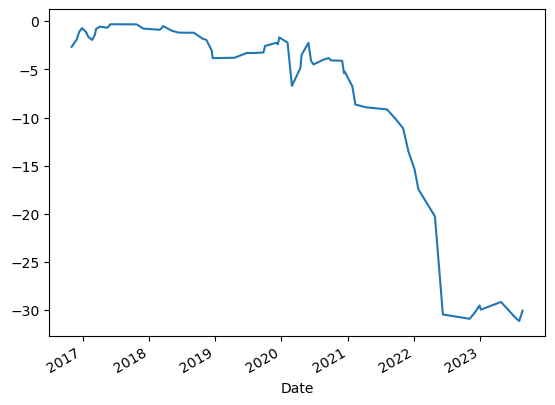

In [10]:
pd.DataFrame(pnl_dict.items(), columns=["Date", "PnL"]).set_index("Date").PnL.cumsum().plot()

## Attempt to optimise this <br>
hold till expiry

In [11]:
pnl_dict = {}

for index, (ironcondor, target_profit, expiry) in ironcondor_tracker.items():
    print(f"Processing date: {index}, expiry: {expiry}")
    if ironcondor is not None:
        try:
            ironcondor.insert_spot(xlu_time_series.loc[expiry]["Close"])
            print(f"---Closing spot: {xlu_time_series.loc[expiry]['Close']}")
        except KeyError:
            ironcondor.insert_spot(xlu_time_series.loc[expiry - pd.Timedelta(days=1)]["Close"])
            print(f"---Closing spot: {xlu_time_series.loc[expiry - pd.Timedelta(days=1)]['Close']}")
        pnl_dict[index] = ironcondor.payoff()

        print(f"-Let iron condor expire: {expiry}, pnl: {pnl_dict[index]}")
        ic_strikes = ironcondor.strikes
        print(f"---strike1: {ic_strikes['strike1']}, strike2: {ic_strikes['strike2']}, strike3: {ic_strikes['strike3']}, strike4: {ic_strikes['strike4']}")

Processing date: 2016-11-01 00:00:00, expiry: 2016-11-11 00:00:00
---Closing spot: 46.220001220703125
-Let iron condor expire: 2016-11-11 00:00:00, pnl: -0.8900000000000001
---strike1: 47.5, strike2: 49.5, strike3: 49.5, strike4: 54.5
Processing date: 2016-11-29 00:00:00, expiry: 2016-12-09 00:00:00
---Closing spot: 47.959999084472656
-Let iron condor expire: 2016-12-09 00:00:00, pnl: 0.7599990844726563
---strike1: 43.0, strike2: 48.0, strike3: 48.0, strike4: 49.0
Processing date: 2016-12-13 00:00:00, expiry: 2016-12-23 00:00:00
---Closing spot: 48.61000061035156
-Let iron condor expire: 2016-12-23 00:00:00, pnl: 0.8099993896484375
---strike1: 46.5, strike2: 48.5, strike3: 48.5, strike4: 49.5
Processing date: 2016-12-28 00:00:00, expiry: 2017-01-06 00:00:00
---Closing spot: 48.83000183105469
-Let iron condor expire: 2017-01-06 00:00:00, pnl: 0.36999816894531246
---strike1: 47.0, strike2: 48.5, strike3: 48.5, strike4: 49.5
Processing date: 2017-01-20 00:00:00, expiry: 2017-02-03 00:00:0

<Axes: xlabel='Date'>

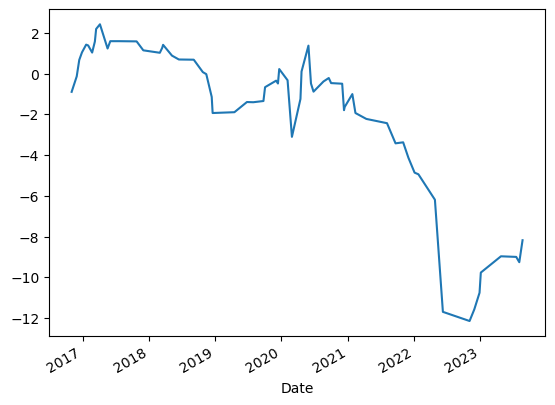

In [12]:
pd.DataFrame(pnl_dict.items(), columns=["Date", "PnL"]).set_index("Date").PnL.cumsum().plot()

Scenario 2: long and short iron condor

In [20]:
ironcondor_tracker = {}

# def find_nearest_strike_delta(date_index, delta_target, option_df, cp_flag):
#     """
#     Helper function to find the strike with delta closest to delta_target
#     """
#     options = option_df.loc[date_index].query(f"cp_flag == '{cp_flag}'")
#     return options.iloc[(options["delta"] - delta_target).abs().argmin()]["strike_price"]

def find_nearest_strike_delta(atm_spot, date_index, delta_target, option_df, cp_flag):
    """
    Helper function to find the strike with delta closest to delta_target
    """

    options = option_df.loc[date_index].query(f"cp_flag == '{cp_flag}'")
    atm_delta = options.query("strike_price == @atm_spot")["delta"]
    try:
        if isinstance(atm_delta, pd.Series):
            atm_delta = atm_delta.values[0]
    except IndexError:
        print(f"Error: {date_index}, {cp_flag}")
        return None
    new_delta = atm_delta + delta_target
    return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]

for index, row in xlu_time_series.iterrows():
    if row["action"] == 1:
        print(f"date: {index}")
        direction = "short"

        index_loc = xlu_time_series.index.get_loc(index)

        current_spot_open = myround(xlu_time_series.iloc[index_loc]["Open"], 0.5)

        daily_options = xlu_filtered_options.loc[index]

        # atm_put_strike = daily_options[
        #     (daily_options["cp_flag"] == "P") &
        #     (daily_options["strike_price"] == prev_spot_close)
        # ]["strike_price"]
        # if isinstance(atm_put_strike, pd.Series):
        #     atm_put_strike = atm_put_strike.values[0]
        
        # atm_call_strike = daily_options[
        #     (daily_options["cp_flag"] == "C") &
        #     (daily_options["strike_price"] == prev_spot_close)
        # ]["strike_price"]
        # if isinstance(atm_call_strike, pd.Series):
        #     atm_call_strike = atm_call_strike.values[0]

        atm_put_strike = atm_call_strike = current_spot_open

        otm_put_strike = find_nearest_strike_delta(current_spot_open, index, 0.4, xlu_filtered_options, "P")
        otm_call_strike = find_nearest_strike_delta(current_spot_open, index, -0.3, xlu_filtered_options, "C")

        if otm_put_strike is None or otm_call_strike is None:
            continue
            
        else:
            print(f"date: {index}, current_spot_open: {current_spot_open}, OTM Put: {otm_put_strike}, ATM Put: {atm_put_strike}, ATM Call: {atm_call_strike}, OTM Call: {otm_call_strike}, \
                left wing: {abs(otm_put_strike - atm_put_strike)}, right wing: {abs(atm_call_strike - otm_call_strike)}")
            strikes = {
                "strike1": otm_put_strike,
                "strike2": atm_put_strike,
                "strike3": atm_call_strike,
                "strike4": otm_call_strike
            }

            premiums = {
                "premium1": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                ],
                "premium2": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                ],
                "premium3": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                ],
                "premium4": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                ]
            }        

            # print(f"date: {index}, Premiums: {premiums}")

            expiry = xlu_filtered_options.loc[index]["exdate"].max()

            ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
            ironcondor_tracker[index] = (ironcondor, ironcondor.target_profit().iloc[0], expiry)
    elif row["action"] == -1:
        print(f"date: {index}")
        direction = "long"

        index_loc = xlu_time_series.index.get_loc(index)

        current_spot_open = myround(xlu_time_series.iloc[index_loc]["Open"], 0.5)

        daily_options = xlu_filtered_options.loc[index]

        # atm_put_strike = daily_options[
        #     (daily_options["cp_flag"] == "P") &
        #     (daily_options["strike_price"] == prev_spot_close)
        # ]["strike_price"]
        # if isinstance(atm_put_strike, pd.Series):
        #     atm_put_strike = atm_put_strike.values[0]
        
        # atm_call_strike = daily_options[
        #     (daily_options["cp_flag"] == "C") &
        #     (daily_options["strike_price"] == prev_spot_close)
        # ]["strike_price"]
        # if isinstance(atm_call_strike, pd.Series):
        #     atm_call_strike = atm_call_strike.values[0]

        atm_put_strike = atm_call_strike = current_spot_open

        otm_put_strike = find_nearest_strike_delta(current_spot_open, index, 0.4, xlu_filtered_options, "P")
        otm_call_strike = find_nearest_strike_delta(current_spot_open, index, -0.3, xlu_filtered_options, "C")

        if otm_put_strike is None or otm_call_strike is None:
            continue
            
        else:
            print(f"date: {index}, current_spot_open: {current_spot_open}, OTM Put: {otm_put_strike}, ATM Put: {atm_put_strike}, ATM Call: {atm_call_strike}, OTM Call: {otm_call_strike}, \
                left wing: {abs(otm_put_strike - atm_put_strike)}, right wing: {abs(atm_call_strike - otm_call_strike)}")
            strikes = {
                "strike1": otm_put_strike,
                "strike2": atm_put_strike,
                "strike3": atm_call_strike,
                "strike4": otm_call_strike
            }

            premiums = {
                "premium1": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike1"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_bid"
                ],
                "premium2": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike2"]) & 
                    (xlu_filtered_options["cp_flag"] == 'P'), "best_offer"
                ],
                "premium3": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike3"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_offer"
                ],
                "premium4": xlu_filtered_options.loc[
                    (xlu_filtered_options.index == index) & 
                    (xlu_filtered_options["strike_price"] == strikes["strike4"]) & 
                    (xlu_filtered_options["cp_flag"] == 'C'), "best_bid"
                ]
            }        

            # print(f"date: {index}, Premiums: {premiums}")

            expiry = xlu_filtered_options.loc[index]["exdate"].max()

            ironcondor = IronCondor(direction=direction, strikes=strikes, premiums=premiums, expiry=expiry)
            ironcondor_tracker[index] = (ironcondor, ironcondor.target_profit().iloc[0], expiry)

date: 2016-11-01 00:00:00
date: 2016-11-01 00:00:00, current_spot_open: 49.5, OTM Put: 47.5, ATM Put: 49.5, ATM Call: 49.5, OTM Call: 54.5,                 left wing: 2.0, right wing: 5.0
date: 2016-11-14 00:00:00
date: 2016-11-14 00:00:00, current_spot_open: 45.5, OTM Put: 40.5, ATM Put: 45.5, ATM Call: 45.5, OTM Call: 47.0,                 left wing: 5.0, right wing: 1.5
date: 2016-11-15 00:00:00
date: 2016-11-15 00:00:00, current_spot_open: 46.5, OTM Put: 42.5, ATM Put: 46.5, ATM Call: 46.5, OTM Call: 47.5,                 left wing: 4.0, right wing: 1.0
date: 2016-11-29 00:00:00
date: 2016-11-29 00:00:00, current_spot_open: 48.0, OTM Put: 43.0, ATM Put: 48.0, ATM Call: 48.0, OTM Call: 49.0,                 left wing: 5.0, right wing: 1.0
date: 2016-12-13 00:00:00
date: 2016-12-13 00:00:00, current_spot_open: 48.5, OTM Put: 46.5, ATM Put: 48.5, ATM Call: 48.5, OTM Call: 49.5,                 left wing: 2.0, right wing: 1.0
date: 2016-12-28 00:00:00
date: 2016-12-28 00:00:00, current

C:\Users\Gavin\AppData\Local\Temp\ipykernel_15380\3226926340.py:24: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]


date: 2017-09-29 00:00:00
date: 2017-09-29 00:00:00, current_spot_open: 53.0, OTM Put: 51.0, ATM Put: 53.0, ATM Call: 53.0, OTM Call: 54.0,                 left wing: 2.0, right wing: 1.0
date: 2017-10-25 00:00:00
date: 2017-10-25 00:00:00, current_spot_open: 54.5, OTM Put: 49.5, ATM Put: 54.5, ATM Call: 54.5, OTM Call: 55.5,                 left wing: 5.0, right wing: 1.0
date: 2017-11-09 00:00:00
date: 2017-11-09 00:00:00, current_spot_open: 55.5, OTM Put: 42.0, ATM Put: 55.5, ATM Call: 55.5, OTM Call: 56.0,                 left wing: 13.5, right wing: 0.5
date: 2017-12-01 00:00:00
date: 2017-12-01 00:00:00, current_spot_open: 57.0, OTM Put: 55.5, ATM Put: 57.0, ATM Call: 57.0, OTM Call: 61.5,                 left wing: 1.5, right wing: 4.5
date: 2017-12-21 00:00:00
date: 2017-12-21 00:00:00, current_spot_open: 52.5, OTM Put: 51.5, ATM Put: 52.5, ATM Call: 52.5, OTM Call: 53.5,                 left wing: 1.0, right wing: 1.0
date: 2018-02-07 00:00:00
date: 2018-02-07 00:00:00, curren

C:\Users\Gavin\AppData\Local\Temp\ipykernel_15380\3226926340.py:24: FutureWarning: The behavior of Series.argmax/argmin with skipna=False and NAs, or with all-NAs is deprecated. In a future version this will raise ValueError.
  return options.iloc[(options["delta"] - new_delta).abs().argmin()]["strike_price"]


date: 2022-08-23 00:00:00
Error: 2022-08-23 00:00:00, P
Error: 2022-08-23 00:00:00, C
date: 2022-09-09 00:00:00
date: 2022-09-09 00:00:00, current_spot_open: 77.5, OTM Put: 74.0, ATM Put: 77.5, ATM Call: 77.5, OTM Call: 79.5,                 left wing: 3.5, right wing: 2.0
date: 2022-10-04 00:00:00
date: 2022-10-04 00:00:00, current_spot_open: 68.0, OTM Put: 45.0, ATM Put: 68.0, ATM Call: 68.0, OTM Call: 70.5,                 left wing: 23.0, right wing: 2.5
date: 2022-11-03 00:00:00
date: 2022-11-03 00:00:00, current_spot_open: 66.0, OTM Put: 45.0, ATM Put: 66.0, ATM Call: 66.0, OTM Call: 68.0,                 left wing: 21.0, right wing: 2.0
date: 2022-11-29 00:00:00
date: 2022-11-29 00:00:00, current_spot_open: 70.0, OTM Put: 67.0, ATM Put: 70.0, ATM Call: 70.0, OTM Call: 72.0,                 left wing: 3.0, right wing: 2.0
date: 2022-12-28 00:00:00
date: 2022-12-28 00:00:00, current_spot_open: 71.5, OTM Put: 69.0, ATM Put: 71.5, ATM Call: 71.5, OTM Call: 74.0,                 left

In [21]:
pnl_dict = {}

for index, (ironcondor, target_profit, expiry) in ironcondor_tracker.items():
    print(f"Processing date: {index}, expiry: {expiry}")
    if ironcondor is not None:
        try:
            ironcondor.insert_spot(xlu_time_series.loc[expiry]["Close"])
        except KeyError:
            ironcondor.insert_spot(xlu_time_series.loc[expiry - pd.Timedelta(days=1)]["Close"])
        pnl_dict[index] = ironcondor.payoff()

Processing date: 2016-11-01 00:00:00, expiry: 2016-11-11 00:00:00
Processing date: 2016-11-14 00:00:00, expiry: 2016-11-25 00:00:00
Processing date: 2016-11-15 00:00:00, expiry: 2016-11-25 00:00:00
Processing date: 2016-11-29 00:00:00, expiry: 2016-12-09 00:00:00
Processing date: 2016-12-13 00:00:00, expiry: 2016-12-23 00:00:00
Processing date: 2016-12-28 00:00:00, expiry: 2017-01-06 00:00:00
Processing date: 2017-01-20 00:00:00, expiry: 2017-02-03 00:00:00
Processing date: 2017-01-31 00:00:00, expiry: 2017-02-10 00:00:00
Processing date: 2017-02-22 00:00:00, expiry: 2017-03-03 00:00:00
Processing date: 2017-03-09 00:00:00, expiry: 2017-03-17 00:00:00
Processing date: 2017-03-16 00:00:00, expiry: 2017-03-24 00:00:00
Processing date: 2017-04-06 00:00:00, expiry: 2017-04-13 00:00:00
Processing date: 2017-05-18 00:00:00, expiry: 2017-05-26 00:00:00
Processing date: 2017-06-02 00:00:00, expiry: 2017-06-16 00:00:00
Processing date: 2017-06-30 00:00:00, expiry: 2017-07-14 00:00:00
Processing

<Axes: xlabel='Date'>

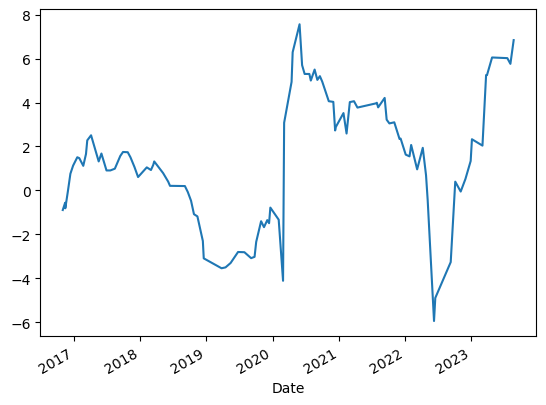

: 

In [ ]:
pd.DataFrame(pnl_dict.items(), columns=["Date", "PnL"]).set_index("Date").PnL.cumsum().plot()